In [ ]:
# 理解rolling()在做什么
# 运行后你会看到前4行是NaN。这是因为第5天才凑齐5个数据点，之前的窗口不完整，所以没有值。
# 这个NaN的处理在回测里非常重要，忘记处理会产生很多bug。

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("7203.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns

close = df["Close"]

# 先看rolling(5)到底产生了什么
window = close.rolling(window=5)
print(type(window))           # 这是一个WindowObject，还没有计算
print(close.rolling(5).mean().head(10))  # 前4个是NaN，第5个才有值

[*********************100%***********************]  1 of 1 completed

<class 'pandas.api.typing.Rolling'>
Date
2024-09-02            NaN
2024-09-03            NaN
2024-09-04            NaN
2024-09-05            NaN
2024-09-06    2559.554150
2024-09-09    2505.981885
2024-09-10    2454.030078
2024-09-11    2405.986621
2024-09-12    2386.349805
2024-09-13    2362.042090
Name: Close, dtype: float64


In [ ]:
# 手写SMA，和pandas对比验证
# 误差接近0就说明你的理解是正确的。

In [2]:
def my_sma(series, window):
    result = pd.Series(index=series.index, dtype=float)
    for i in range(len(series)):
        if i < window - 1:
            result.iloc[i] = float('nan')
        else:
            result.iloc[i] = series.iloc[i - window + 1 : i + 1].mean()
    return result

# 对比：手写 vs pandas
sma5_manual = my_sma(close, 5)
sma5_pandas = close.rolling(5).mean()

diff = (sma5_manual - sma5_pandas).abs().max()
print(f"最大误差：{diff:.10f}")  # 应该接近于0

最大误差：0.0000000000


In [ ]:
# 理解EMA——为什么它比SMA更敏感
# SMA对所有数据一视同仁，10天前的价格和昨天的价格权重相同。EMA（指数移动平均）则给**越近的数据越高的权重**，公式是：
# EMA今天 = 价格今天 × α + EMA昨天 × (1 - α)
# 其中 α = 2 / (N + 1)

In [3]:
def my_ema(series, window):
    alpha = 2 / (window + 1)
    result = pd.Series(index=series.index, dtype=float)
    
    # 第一个有效值用SMA初始化（pandas的标准做法）
    result.iloc[window - 1] = series.iloc[:window].mean()
    
    for i in range(window, len(series)):
        result.iloc[i] = series.iloc[i] * alpha + result.iloc[i-1] * (1 - alpha)
    
    return result

ema5_manual = my_ema(close, 5)
ema5_pandas = close.ewm(span=5, adjust=False).mean()

# 对比两种实现
print(ema5_manual.tail(10))
print(ema5_pandas.tail(10))

Date
2025-02-14    2733.957363
2025-02-17    2717.033424
2025-02-18    2715.586410
2025-02-19    2698.981435
2025-02-20    2673.399895
2025-02-21    2654.894445
2025-02-25    2644.008569
2025-02-26    2641.427262
2025-02-27    2658.732677
2025-02-28    2639.634122
dtype: float64
Date
2025-02-14    2733.957363
2025-02-17    2717.033424
2025-02-18    2715.586410
2025-02-19    2698.981435
2025-02-20    2673.399895
2025-02-21    2654.894445
2025-02-25    2644.008569
2025-02-26    2641.427262
2025-02-27    2658.732677
2025-02-28    2639.634122
Name: Close, dtype: float64


In [ ]:
# 三条线画在一起，看差异
# 图出来后，观察一件事：SMA5（橙）和EMA5（红）走势非常相似，但EMA在价格急剧变动时反应更快，能更早地追上价格转折点。
# 这就是为什么很多交易者偏好EMA作为信号线。

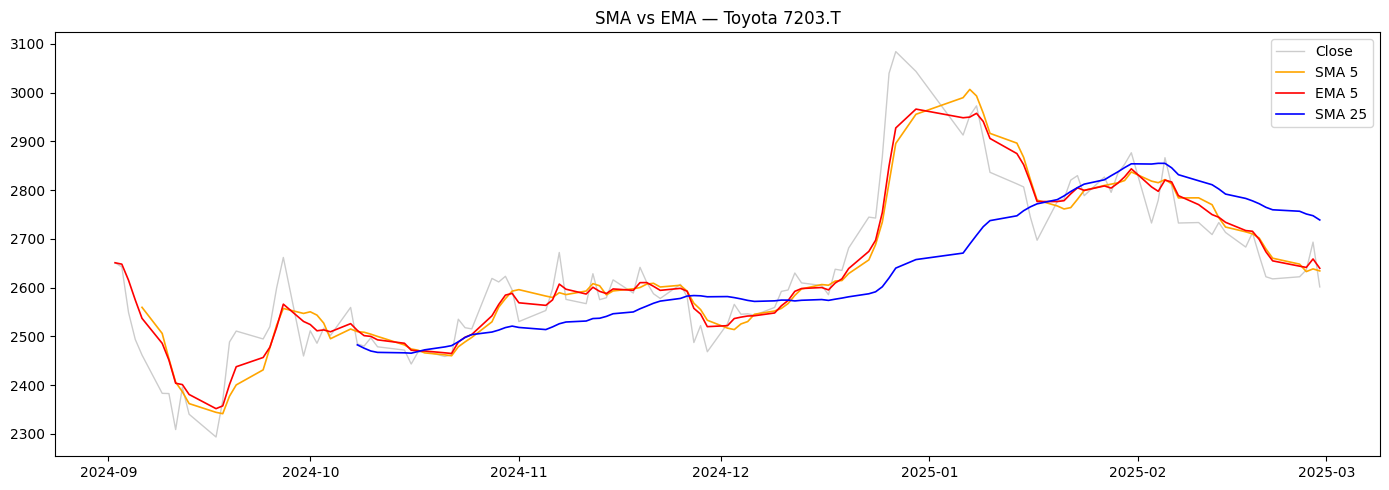

In [4]:
sma5  = close.rolling(5).mean()
sma25 = close.rolling(25).mean()
ema5  = close.ewm(span=5, adjust=False).mean()

plt.figure(figsize=(14, 5))
plt.plot(close, color="gray",   alpha=0.4, linewidth=1,   label="Close")
plt.plot(sma5,  color="orange", linewidth=1.2, label="SMA 5")
plt.plot(ema5,  color="red",    linewidth=1.2, label="EMA 5")
plt.plot(sma25, color="blue",   linewidth=1.2, label="SMA 25")
plt.title("SMA vs EMA — Toyota 7203.T")
plt.legend()
plt.tight_layout()
plt.show()